# Experiment 1: Data Analysis & Visualization Pipeline

## Objective
Perform data analysis on `student_performance.csv` covering:
1.  **NumPy**: Array manipulation and normalization.
2.  **Pandas**: Data loading, inspection, and transformation.
3.  **Matplotlib**: Basic plotting.
4.  **Seaborn**: Statistical visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots display inline
%matplotlib inline

## Exercise 1: NumPy Basics
1. Load `Final_Score` as NumPy array.
2. Compute mean, median, and standard deviation.
3. Perform Min-Max normalization.

In [2]:
# 1. Load Final_Score column (using pandas for robust loading, then converting to numpy)
df_raw = pd.read_csv('student_performance.csv')
final_scores = df_raw['Final_Score'].to_numpy()

print("Final Scores Array:", final_scores)

# 2. Compute Statistics
mean_val = np.mean(final_scores)
median_val = np.median(final_scores)
std_val = np.std(final_scores)

print(f"\nMean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

# 3. Min-Max Normalization
# Formula: (x - min) / (max - min)
min_val = np.min(final_scores)
max_val = np.max(final_scores)

normalized_scores = (final_scores - min_val) / (max_val - min_val)

print("\nNormalized Scores (First 5):", normalized_scores[:5])

Final Scores Array: [52 57 60 64 68 71 74 77 79 83 63 70 75 56 69 73 80 58 72 78]

Mean: 68.95
Median: 70.50
Standard Deviation: 8.71

Normalized Scores (First 5): [0.         0.16129032 0.25806452 0.38709677 0.51612903]


## Exercise 2: Pandas Data Handling
1. Load CSV file using Pandas.
2. Check shape, columns, and missing values.
3. Create `Performance` label based on `Final_Score`.

In [3]:
# 1. Load CSV
df = pd.read_csv('student_performance.csv')

# 2. Check Data Properties
print("Shape of Dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

# 3. Create Performance Label
# Logic: >=75: 'Excellent', >=60: 'Good', <60: 'Average'
def categorize_performance(score):
    if score >= 75:
        return 'Excellent'
    elif score >= 60:
        return 'Good'
    else:
        return 'Average'

df['Performance'] = df['Final_Score'].apply(categorize_performance)

print("\nUpdated DataFrame Head:")
display(df.head())

Shape of Dataset: (20, 5)

Columns: ['Hours_Studied', 'Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score']

Missing Values:
 Hours_Studied       0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64

Updated DataFrame Head:


,Hours_Studied,Attendance,Assignment_Score,Midterm_Score,Final_Score,Performance
0,1,60,55,50,52,Average
1,2,65,58,55,57,Average
2,3,70,60,58,60,Good
3,4,75,65,62,64,Good
4,5,80,68,65,68,Good


## Exercise 3: Matplotlib Visualization
1. Line plot: `Hours_Studied` vs `Final_Score`.
2. Histogram of `Final_Score`.

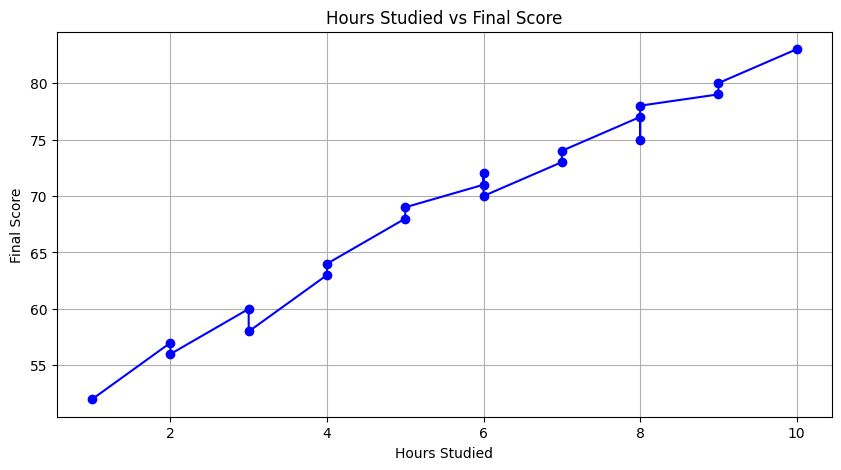

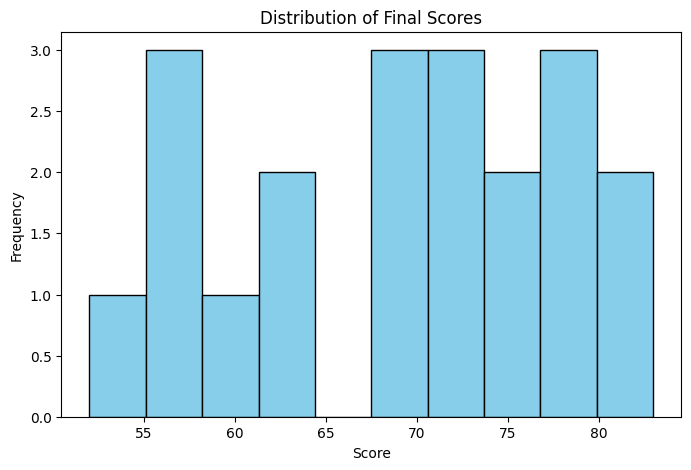

In [4]:
# 1. Line Plot
# Sorting by Hours_Studied to ensure the line plot makes sense visually
df_sorted = df.sort_values('Hours_Studied')

plt.figure(figsize=(10, 5))
plt.plot(df_sorted['Hours_Studied'], df_sorted['Final_Score'], marker='o', linestyle='-', color='b')
plt.title('Hours Studied vs Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.grid(True)
plt.show()

# 2. Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['Final_Score'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

## Exercise 4: Seaborn Visualization
1. Scatter plot using seaborn.
2. Heatmap for correlation analysis.
3. Boxplot for categorical analysis.

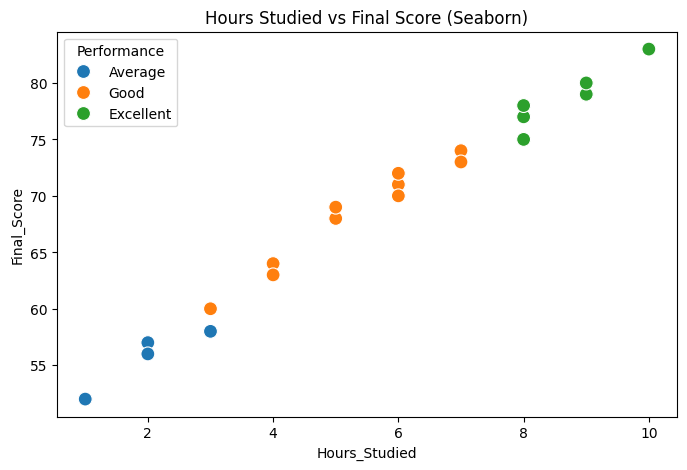

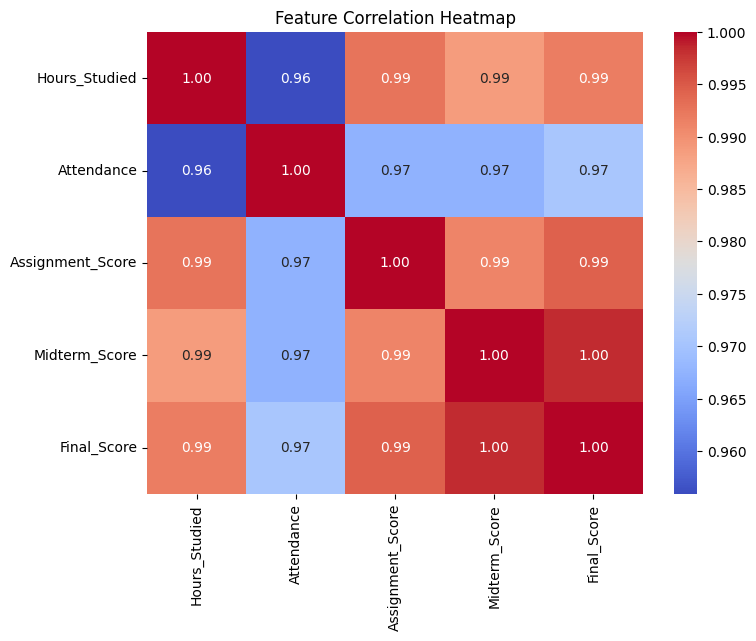

C:\Users\heram\AppData\Local\Temp\ipykernel_151880\4200145041.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Performance', y='Hours_Studied', data=df, palette="Set2")


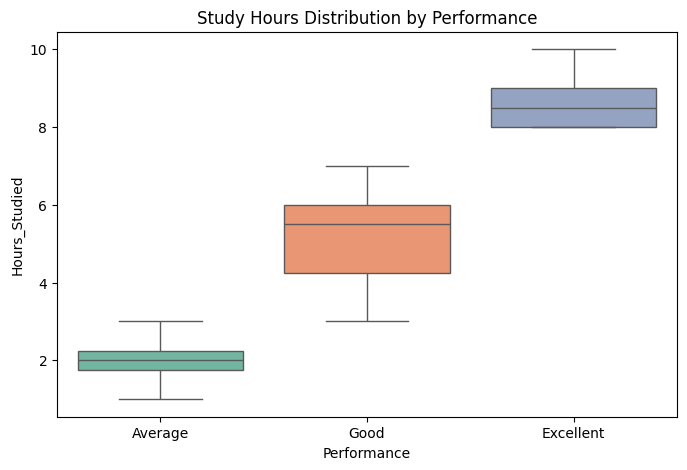

In [5]:
# 1. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hours_Studied', y='Final_Score', hue='Performance', data=df, s=100)
plt.title('Hours Studied vs Final Score (Seaborn)')
plt.show()

# 2. Heatmap
plt.figure(figsize=(8, 6))
# Filter only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Boxplot
# Analyzing Score distribution across different Attendance levels or Performance groups
plt.figure(figsize=(8, 5))
sns.boxplot(x='Performance', y='Hours_Studied', hue='Performance', data=df, palette="Set2", legend=False)
plt.title('Study Hours Distribution by Performance')
plt.show()